# Document Classification: Hybrid EfficientNet-B0 + Vision Transformer
















This notebook trains a hybrid convolutional-transformer model for document categorization.
The model combines:
- **EfficientNet-B0** for local feature extraction (borders, stamps, text texture)
- **Vision Transformer (ViT)** encoder for global structure understanding (layout, sections)

## Key Features
- Automatic Mixed Precision (AMP) for speed and memory efficiency
- Weighted CrossEntropyLoss to handle class imbalance
- Two-phase learning rates to prevent catastrophic forgetting
- Early stopping and ReduceLROnPlateau scheduling
- Document-specific augmentations (skew, blur, color variation)
- Confidence distribution analysis for uncertainty detection

## 1. Setup and Imports

In [1]:
!pip install -q py7zr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.2/494.2 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 18.1 MB/s eta 0:00:00


In [2]:
import os
import torch
from torch import nn, optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time
import logging
import random
from pathlib import Path
from google.colab import drive
from torch.optim.lr_scheduler import OneCycleLR
import zipfile
import py7zr, gdown
from torch.utils.data import WeightedRandomSampler

# Jupyter-specific
%matplotlib inline

print("✓ Imports successful")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
drive.mount('/content/drive')

✓ Imports successful
PyTorch version: 2.10.0+cu128
CUDA available: True
Mounted at /content/drive


In [3]:
zip_path = '/content/drive/MyDrive/SAMPLE DATA.7z'
extract_path = '/content/SAMPLE DATA'

if not os.path.exists(extract_path):
    with py7zr.SevenZipFile(zip_path, 'r') as z:
        z.extractall(extract_path)
    print(f"Extracted all")
else:
    print(f"Data already extracted in ")

file_id = '1J5nHAaOg87ODoYYJdN4Zcz8-CWLV9_9n'
url = f'https://drive.google.com/uc?id={file_id}'

# Download the file
gdown.download(url, "class_mapping.csv", quiet=False)

Extracted all


Downloading...
From: https://drive.google.com/uc?id=1J5nHAaOg87ODoYYJdN4Zcz8-CWLV9_9n
To: /content/class_mapping.csv
100%|██████████| 487/487 [00:00<00:00, 1.77MB/s]


'class_mapping.csv'

## 2. Configuration and Setup

In [4]:
# Configuration
config = {
    'data_dir': '/content/SAMPLE DATA/SAMPLE DATA',
    'output_dir': "'/content/drive/MyDrive/EDS_MODELS",
    'batch_size': 32,
    'epochs': 30,
    'learning_rate': 1e-4,
    'weight_decay': 1e-4,
    'val_split': 0.15,
    'test_split': 0.15,
    'num_workers': 4,  # Set to 0 for Jupyter on Windows
    'patience': 5,
    'confidence_threshold': 0.70,
    'freeze_backbone': False,
}

# Create output directory
os.makedirs(config['output_dir'], exist_ok=True)

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
)
logger = logging.getLogger(__name__)

# Device
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    logger.info(f"GPU: {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    logger.info(f"VRAM: {vram:.1f} GB")
else:
    device = torch.device("cpu")
    logger.info("CUDA not available — training on CPU")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.benchmark = True

print(f"✓ Configuration set. Device: {device}")

✓ Configuration set. Device: cuda:0


## 3. Dataset, Transforms, and Data Loading

In [5]:
IMAGE_EXTENSIONS = ('*.jpg', '*.jpeg', '*.png', '*.tiff', '*.tif', '*.bmp')

class DocumentDataset(Dataset):
    """Loads document images with resilience to corrupt files."""
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        try:
            image = Image.open(self.image_paths[idx]).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, self.labels[idx]
        except Exception as e:
            logger.error(f"Error loading image {self.image_paths[idx]}: {e}")
            return torch.zeros(3, 224, 224), self.labels[idx]

def get_transforms():
    """Document-specific augmentations."""
    train_transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomAffine(degrees=5, translate=(0.05, 0.05), shear=5),
        transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 2.0)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    eval_transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    return {'train': train_transform, 'eval': eval_transform}

def prepare_dataset(data_dir, output_dir, val_split=0.15, test_split=0.15):
    """Prepare datasets with stratified split."""
    data_dir     = Path(data_dir)
    all_images   = []
    all_labels   = []
    class_to_idx = {}

    for idx, category_dir in enumerate(sorted([d for d in data_dir.iterdir() if d.is_dir()])):
        category_name = category_dir.name
        class_to_idx[category_name] = idx
        logger.info(f"Category: {category_name}  (idx={idx})")

        category_images = []
        for ext in IMAGE_EXTENSIONS:
            category_images.extend(category_dir.glob(ext))

        logger.info(f"  -> {len(category_images)} images")
        for img_path in category_images:
            all_images.append(str(img_path))
            all_labels.append(idx)

    X_train, X_temp, y_train, y_temp = train_test_split(
        all_images, all_labels, test_size=val_split + test_split,
        stratify=all_labels, random_state=42,
    )
    test_ratio = test_split / (val_split + test_split)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=test_ratio,
        stratify=y_temp, random_state=42,
    )

    logger.info(f"Split -> Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")

    idx_to_class = {v: k for k, v in class_to_idx.items()}
    pd.DataFrame({
        'class_idx':  list(idx_to_class.keys()),
        'class_name': list(idx_to_class.values()),
    }).to_csv(Path(output_dir) / 'class_mapping.csv', index=False)
    logger.info(f"Class mapping saved -> {Path(output_dir) / 'class_mapping.csv'}")

    return {
        'train':        (X_train, y_train),
        'val':          (X_val,   y_val),
        'test':         (X_test,  y_test),
        'class_to_idx': class_to_idx,
        'idx_to_class': idx_to_class,
    }

logger.info("Preparing datasets...")
datasets    = prepare_dataset(config['data_dir'], config['output_dir'],
                               config['val_split'], config['test_split'])
tf          = get_transforms()
num_classes = len(datasets['class_to_idx'])
logger.info(f"Classes ({num_classes}): {list(datasets['class_to_idx'].keys())}")

# Class weights
y_train              = np.array(datasets['train'][1])
class_weights        = compute_class_weight(
    'balanced', classes=np.unique(y_train), y=y_train
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
logger.info(f"Class weights (sampled): {dict(list(enumerate(class_weights.round(3)))[:5])}")

print(f"✓ Dataset prepared: {num_classes} classes, ~{len(y_train)} training images")

✓ Dataset prepared: 19 classes, ~16185 training images


## 4. Model Architecture: Hybrid EfficientNet-B0 + ViT

In [6]:
class HybridDocumentClassifier(nn.Module):
    """EfficientNet-B0 backbone + Vision Transformer encoder."""
    def __init__(self, num_classes, freeze_backbone=False, vit_hidden_dim=768,
                 vit_layers=4, vit_heads=8, dropout=0.2):
        super().__init__()

        # EfficientNet-B0 backbone
        eff = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.efficientnet = nn.Sequential(*list(eff.children())[:-2])
        eff_out_channels  = 1280

        if freeze_backbone:
            for p in self.efficientnet.parameters():
                p.requires_grad = False

        self.patch_projection = nn.Linear(eff_out_channels, vit_hidden_dim)

        # [CLS] token and positional embeddings
        self.cls_token = nn.Parameter(torch.zeros(1, 1, vit_hidden_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        self.pos_embedding = nn.Parameter(torch.zeros(1, 50, vit_hidden_dim))
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=vit_hidden_dim, nhead=vit_heads,
            dim_feedforward=vit_hidden_dim * 4, dropout=dropout,
            activation='gelu', batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=vit_layers)

        # Classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(vit_hidden_dim), nn.Dropout(dropout),
            nn.Linear(vit_hidden_dim, 512), nn.BatchNorm1d(512), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(512, num_classes),
        )

    def forward(self, x):
        B = x.size(0)
        feat_map = self.efficientnet(x)                  # [B, 1280, 7, 7]
        patches  = feat_map.flatten(2).transpose(1, 2)   # [B, 49, 1280]
        patches  = self.patch_projection(patches)        # [B, 49, 768]
        cls      = self.cls_token.expand(B, -1, -1)      # [B, 1, 768]
        tokens   = torch.cat([cls, patches], dim=1)      # [B, 50, 768]
        tokens   = tokens + self.pos_embedding
        tokens   = self.transformer(tokens)              # [B, 50, 768]
        return self.classifier(tokens[:, 0])             # [B, num_classes]

print("✓ Model architecture defined")

✓ Model architecture defined


6. Create DataLoaders and Training Functions

In [7]:
# ## 5. Create DataLoaders

# def make_loader(split, shuffle):
#     return DataLoader(
#         DocumentDataset(
#             datasets[split][0], datasets[split][1],
#             tf['train'] if split == 'train' else tf['eval'],
#         ),
#         batch_size=config['batch_size'], shuffle=shuffle,
#         num_workers=config['num_workers'], pin_memory=(device.type == 'cuda'),
#     )

# logger.info("Creating DataLoaders...")
# train_loader = make_loader('train', shuffle=True)
# val_loader   = make_loader('val',   shuffle=False)
# test_loader  = make_loader('test',  shuffle=False)

# print(f"✓ DataLoaders created")
# print(f"  Train batches: {len(train_loader)}")
# print(f"  Val batches:   {len(val_loader)}")
# print(f"  Test batches:  {len(test_loader)}")

# Creating Dataloaders with WeightedRandomSampler

# Map the pre-calculated class weights to every single training sample
from torch.utils.data import WeightedRandomSampler

## Create DataLoaders (with WeightedRandomSampler)

# Map the pre-calculated class_weights to every single training sample
y_train_list = datasets['train'][1]
sample_weights = [class_weights[label] for label in y_train_list]

# Create the PyTorch Sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Update the loader function to accept the sampler
def make_loader(split, is_train=False):
    dataset = DocumentDataset(
        datasets[split][0], datasets[split][1],
        tf['train'] if split == 'train' else tf['eval'],
    )

    if is_train:
        # For training: use the sampler, and shuffle MUST be omitted/False
        return DataLoader(
            dataset,
            batch_size=config['batch_size'],
            sampler=sampler,
            num_workers=config['num_workers'],
            pin_memory=(device.type == 'cuda')
        )
    else:
        # For validation/testing: no sampler needed, no shuffling needed
        return DataLoader(
            dataset,
            batch_size=config['batch_size'],
            shuffle=False,
            num_workers=config['num_workers'],
            pin_memory=(device.type == 'cuda')
        )

logger.info("Creating DataLoaders...")
train_loader = make_loader('train', is_train=True)
val_loader   = make_loader('val',   is_train=False)
test_loader  = make_loader('test',  is_train=False)

print(f"✓ DataLoaders created (Training uses WeightedRandomSampler)")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")

✓ DataLoaders created (Training uses WeightedRandomSampler)
  Train batches: 506
  Val batches:   109
  Test batches:  109


## 5. Build Model, Optimizer, and Scheduler

In [8]:
## 6. Build Model, Optimizer, and Scheduler

logger.info("Building Hybrid EfficientNet-B0 + ViT model...")
model = HybridDocumentClassifier(
    num_classes=num_classes, freeze_backbone=config['freeze_backbone'],
    vit_hidden_dim=768, vit_layers=4, vit_heads=8, dropout=0.2,
)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
logger.info(f"Parameters: {trainable:,} trainable / {total:,} total")

# Loss function
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)

# Optimizer: two-phase LR (backbone 10x slower)
def build_optimizer(model, lr_backbone, lr_head, weight_decay):
    return optim.AdamW([
        {'params': model.efficientnet.parameters(),       'lr': lr_backbone},
        {'params': model.patch_projection.parameters(),   'lr': lr_head},
        {'params': [model.cls_token, model.pos_embedding],'lr': lr_head},
        {'params': model.transformer.parameters(),        'lr': lr_head},
        {'params': model.classifier.parameters(),         'lr': lr_head},
    ], weight_decay=weight_decay)

optimizer = build_optimizer(
    model,
    lr_backbone  = config['learning_rate'] * 0.1,
    lr_head      = config['learning_rate'],
    weight_decay = config['weight_decay'],
)

# Scheduler: OneCycleLR
scheduler = OneCycleLR(
    optimizer,
    max_lr=[config['learning_rate'] * 0.1,
            config['learning_rate'], config['learning_rate'],
            config['learning_rate'], config['learning_rate']],
    steps_per_epoch=len(train_loader),
    epochs=config['epochs'],
    pct_start=0.1,
)

print(f"✓ Model, optimizer, and scheduler configured")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 150MB/s]


✓ Model, optimizer, and scheduler configured


/tmp/ipykernel_4836/1124110266.py:31: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=vit_layers)


## 7. Define Training Loop

In [9]:
def train_model(model, dataloaders, criterion, optimizer, scheduler, device,
                 num_epochs=30, checkpoint_dir='checkpoints', patience=5):
    """Training loop with AMP, gradient clipping, and early stopping."""
    os.makedirs(checkpoint_dir, exist_ok=True)
    model = model.to(device)
    scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc, epochs_no_improve = 0.0, 0
    start_time = time.time()

    for epoch in range(num_epochs):
        logger.info(f'Epoch {epoch+1}/{num_epochs}')
        logger.info('-' * 50)

        for phase in ['train', 'val']:
            is_train = (phase == 'train')
            model.train() if is_train else model.eval()
            running_loss, running_corrects = 0.0, 0
            pbar = tqdm(dataloaders[phase], desc=f"{phase.capitalize()} {epoch+1}/{num_epochs}")

            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(is_train):
                    with torch.autocast('cuda', enabled=(device.type == 'cuda')):
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if is_train:
                        if scaler:
                            scaler.scale(loss).backward()
                            scaler.unscale_(optimizer)
                            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                            scaler.step(optimizer)
                            scaler.update()
                        else:
                            loss.backward()
                            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                            optimizer.step()
                        scheduler.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels)
                pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{(preds == labels).float().mean():.4f}'})

            n, epoch_loss = len(dataloaders[phase].dataset), running_loss / len(dataloaders[phase].dataset)
            epoch_acc = (running_corrects.double() / n).item()
            logger.info(f"{phase.capitalize()} -> loss: {epoch_loss:.4f}  acc: {epoch_acc:.4f}")

            if is_train:
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc)

                if epoch_acc > best_val_acc:
                    best_val_acc, epochs_no_improve = epoch_acc, 0
                    torch.save({'epoch': epoch+1, 'model_state_dict': model.state_dict(),
                               'optimizer_state_dict': optimizer.state_dict(), 'val_acc': best_val_acc,
                               'model_arch': {'vit_hidden_dim': model.patch_projection.out_features,
                                             'vit_layers': len(model.transformer.layers),
                                             'vit_heads': model.transformer.layers[0].self_attn.num_heads}},
                              os.path.join(checkpoint_dir, 'best_model.pt'))
                    logger.info(f"  + Best model saved (val_acc={best_val_acc:.4f})")
                else:
                    epochs_no_improve += 1
                    logger.info(f"  No improvement: {epochs_no_improve}/{patience} epochs")

        if epochs_no_improve >= patience:
            logger.info(f"Early stopping at epoch {epoch+1}")
            break

        logger.info(f"Elapsed: {(time.time()-start_time)/60:.1f} min\\n")

    torch.save({'model_state_dict': model.state_dict(), 'history': history},
              os.path.join(checkpoint_dir, 'final_model.pt'))
    total = time.time() - start_time
    logger.info(f'Training complete in {total//60:.0f}m {total%60:.0f}s | Best val_acc: {best_val_acc:.4f}')
    return model, history

print("✓ Training function defined")

✓ Training function defined


## 8. Execute Training

**Note:** Training will run for several hours on CPU. On GPU, expect 30-45 minutes.

In [10]:
trained_model, history = train_model(
    model,
    {'train': train_loader, 'val': val_loader},
    criterion, optimizer, scheduler, device,
    num_epochs=config['epochs'],
    checkpoint_dir=config['output_dir'],
    patience=config['patience'],
)
print("✓ Training complete!")

Train 1/30:   0%|          | 0/506 [00:00<?, ?it/s]/tmp/ipykernel_4836/3841674312.py:43: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
Val 29/30: 100%|██████████| 109/109 [02:36<00:00,  1.44s/it, loss=3.2913, acc=0.8333]


✓ Training complete!


## 9. Plot Training History

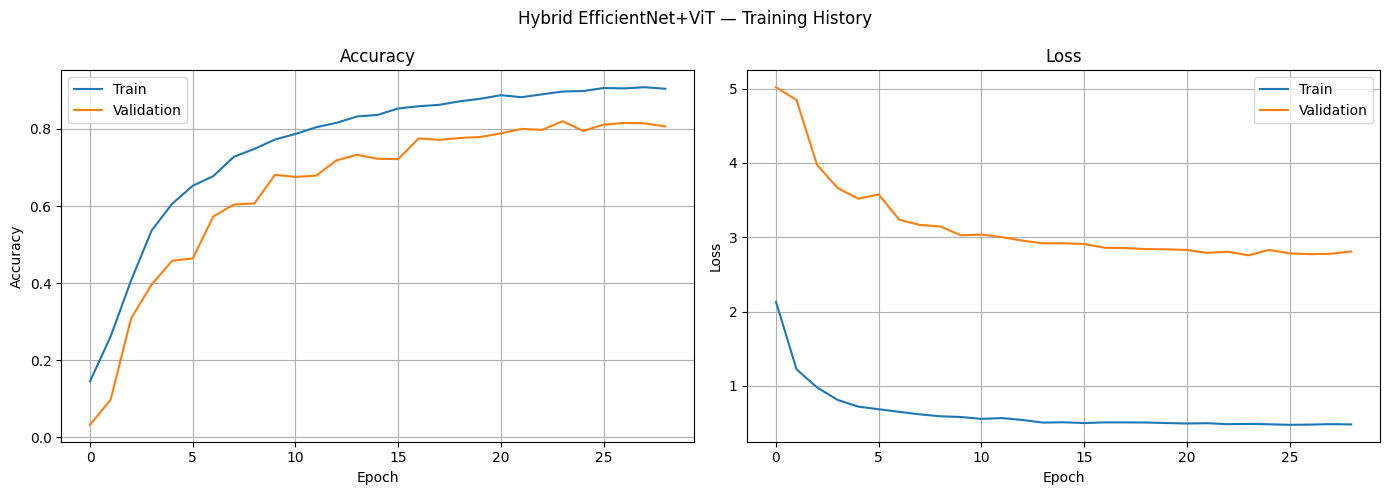

✓ Training history plotted and saved


In [11]:
def plot_training_history(history, output_dir='results'):
    os.makedirs(output_dir, exist_ok=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history['train_acc'], label='Train')
    axes[0].plot(history['val_acc'], label='Validation')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(history['train_loss'], label='Train')
    axes[1].plot(history['val_loss'], label='Validation')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid()

    plt.suptitle('Hybrid EfficientNet+ViT — Training History')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'training_history.png'), dpi=300)
    plt.show()

    pd.DataFrame(history).to_csv(os.path.join(output_dir, 'training_history.csv'), index=False)

plot_training_history(history, output_dir=config['output_dir'])
print("✓ Training history plotted and saved")

## 10. Evaluate on Test Set

Evaluating: 100%|██████████| 109/109 [02:39<00:00,  1.47s/it]


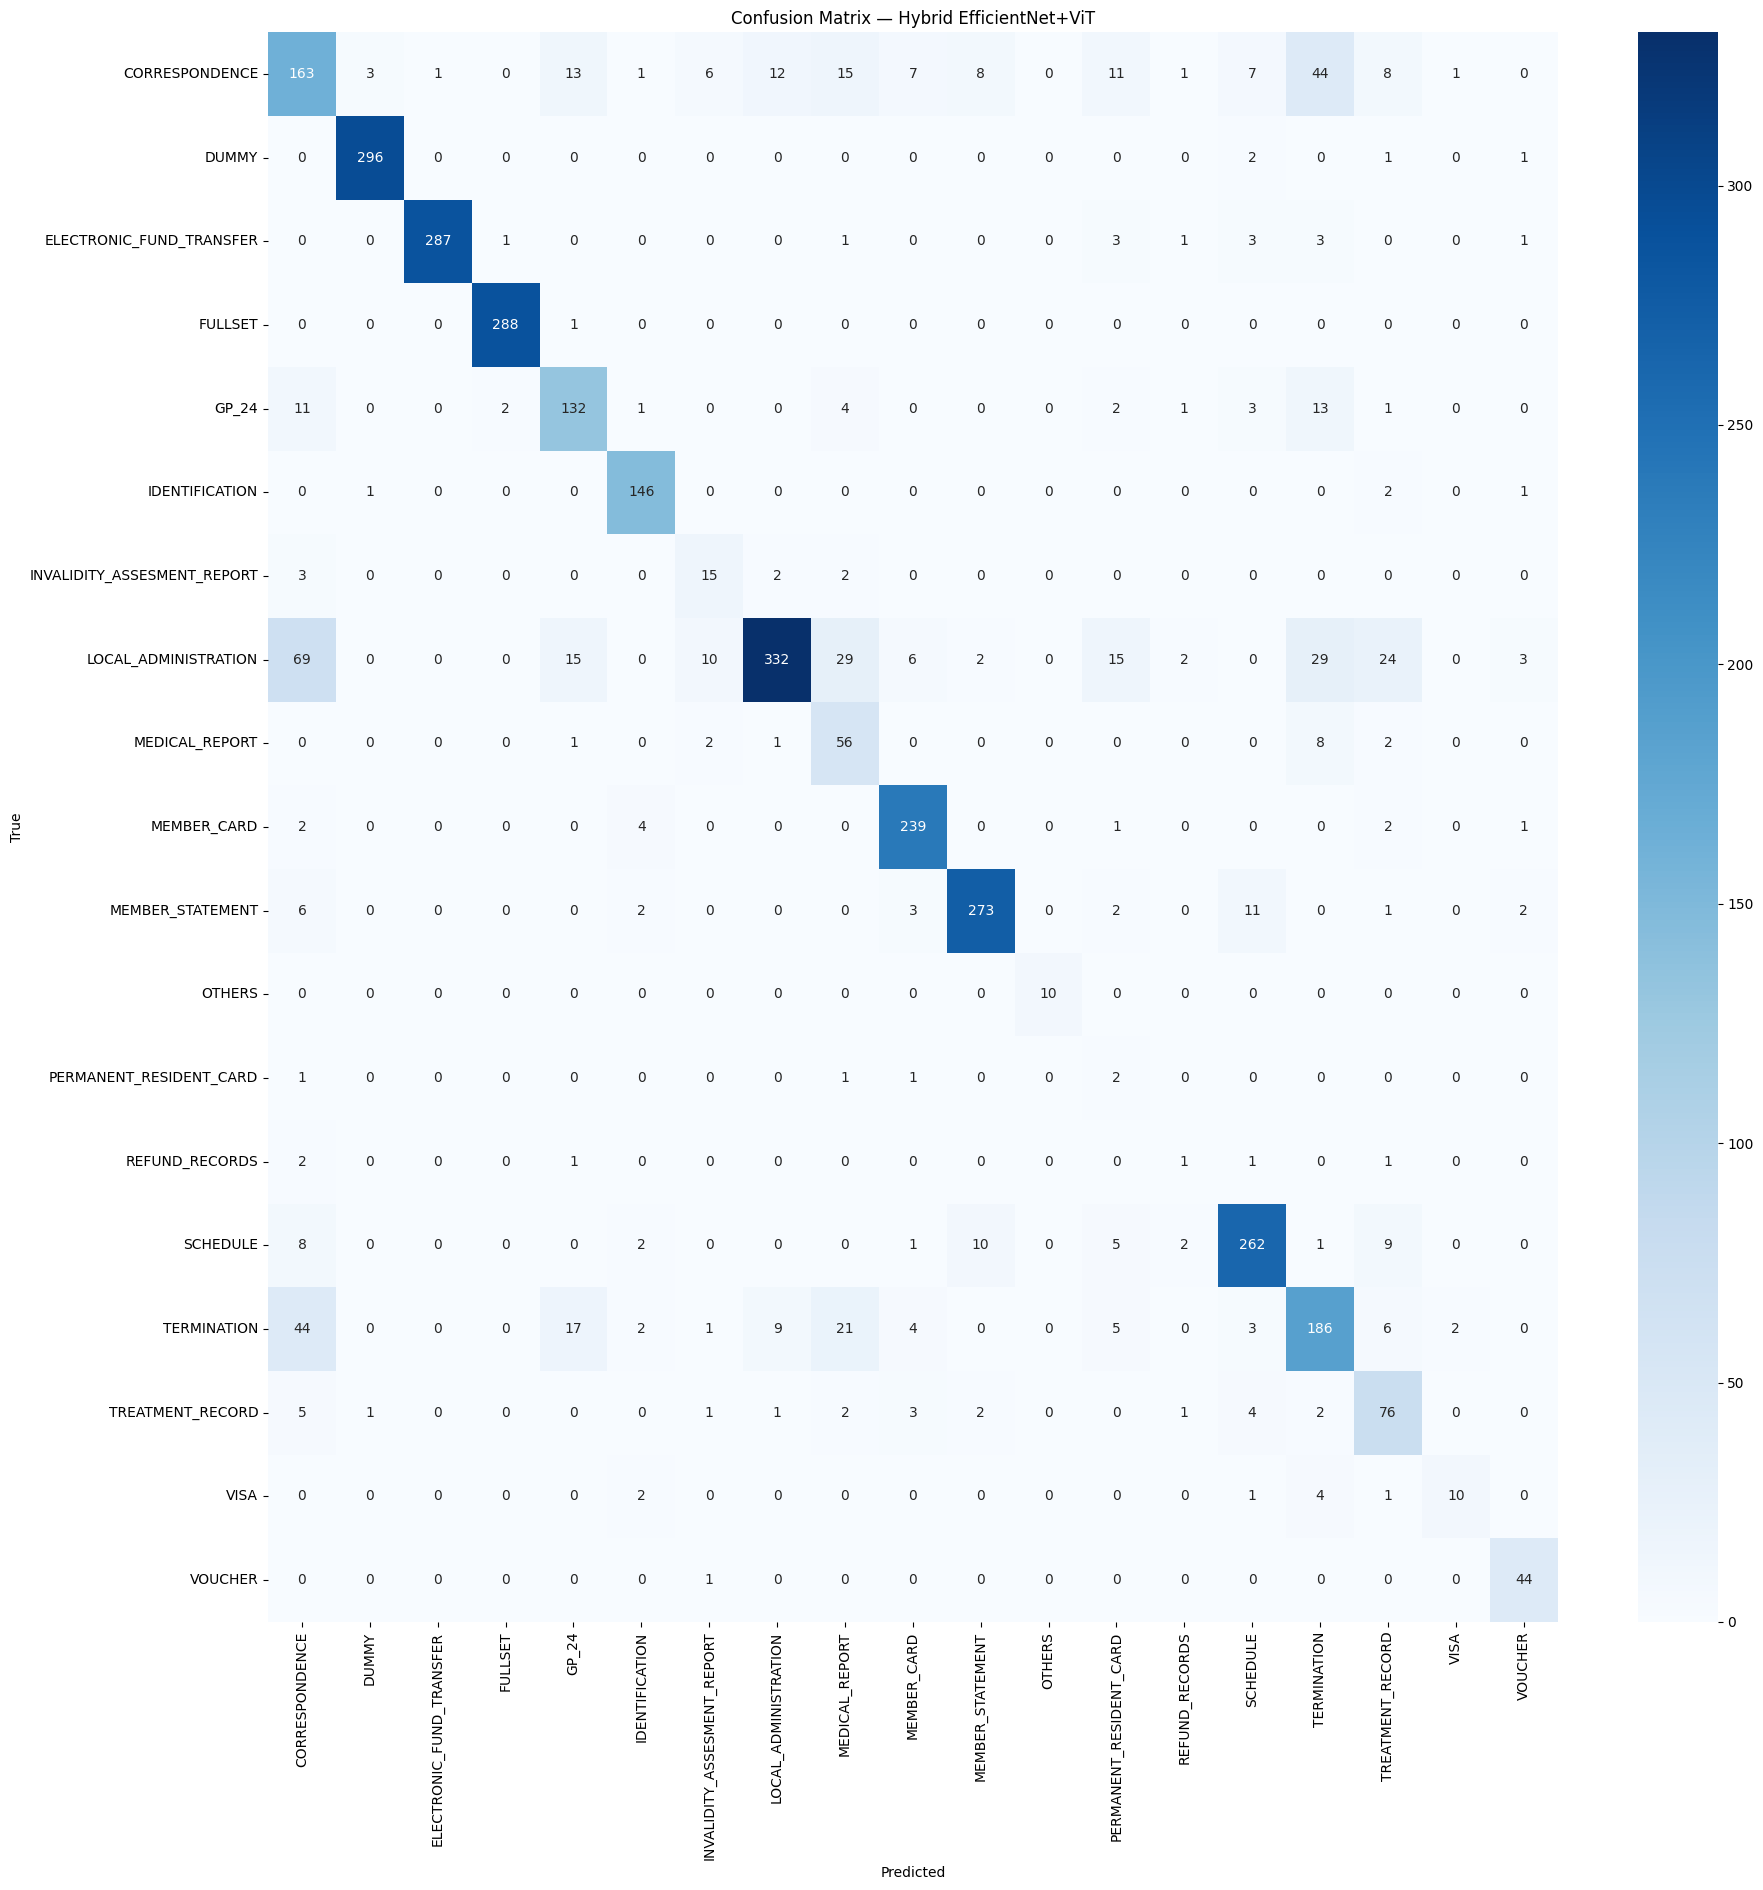

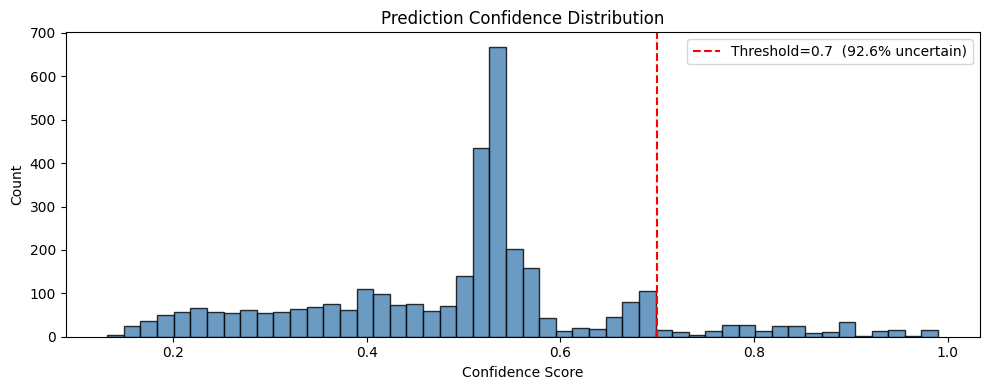

✓ Evaluation complete!
Test Accuracy: 0.8123
Mean Confidence: 0.4956
Uncertain predictions: 92.6%


In [12]:
def evaluate_model(model, test_loader, idx_to_class, device, output_dir='results', confidence_threshold=0.70):
    """Evaluate model, save confusion matrix, confidence distribution, and classification report."""
    os.makedirs(output_dir, exist_ok=True)
    model.eval()
    model = model.to(device)

    all_preds, all_labels, all_confidences = [], [], []
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Evaluating"):
            inputs = inputs.to(device)
            with torch.autocast('cuda', enabled=(device.type == 'cuda')):
                outputs = model(inputs)
            probs, preds = torch.max(torch.softmax(outputs, dim=1), dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_confidences.extend(probs.cpu().numpy())

    class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

    # Classification report
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    pd.DataFrame(report).transpose().to_csv(os.path.join(output_dir, 'classification_report.csv'))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(max(10, len(class_names)), max(8, len(class_names))))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix — Hybrid EfficientNet+ViT')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'confusion_matrix.png'), dpi=300)
    plt.show()

    # Confidence distribution
    confs = np.array(all_confidences)
    below = (confs < confidence_threshold).mean() * 100
    plt.figure(figsize=(10, 4))
    plt.hist(confs, bins=50, edgecolor='black', color='steelblue', alpha=0.8)
    plt.axvline(confidence_threshold, color='red', linestyle='--',
                label=f'Threshold={confidence_threshold}  ({below:.1f}% uncertain)')
    plt.xlabel('Confidence Score')
    plt.ylabel('Count')
    plt.title('Prediction Confidence Distribution')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'confidence_distribution.png'), dpi=300)
    plt.show()

    accuracy = (np.array(all_preds) == np.array(all_labels)).mean()
    logger.info(f"Test Accuracy: {accuracy:.4f}")
    logger.info(f"Mean Confidence: {confs.mean():.4f}")
    logger.info(f"Uncertain (<{confidence_threshold}): {below:.1f}%")

    return {'accuracy': accuracy, 'report': report, 'cm': cm,
            'mean_confidence': float(confs.mean()), 'uncertain_pct': float(below)}

logger.info("Evaluating on test set...")
eval_results = evaluate_model(
    trained_model, test_loader, datasets['idx_to_class'], device,
    output_dir=config['output_dir'], confidence_threshold=config['confidence_threshold'],
)

print("✓ Evaluation complete!")
print(f"Test Accuracy: {eval_results['accuracy']:.4f}")
print(f"Mean Confidence: {eval_results['mean_confidence']:.4f}")
print(f"Uncertain predictions: {eval_results['uncertain_pct']:.1f}%")

## 11. Summary and Next Steps

### Results Summary
- **Test Accuracy**: Review metrics above
- **Model Checkpoints**: Saved in `C:\Users\IT\Desktop\EDS_MODELS\output\`
- **Confidence Analysis**: See `confidence_distribution.png` for uncertain predictions

### Files Generated
- `best_model.pt` — Best model checkpoint
- `final_model.pt` — Final model after training
- `class_mapping.csv` — Class index mapping
- `training_history.csv` — Per-epoch metrics
- `classification_report.csv` — Per-class F1, precision, recall
- `confusion_matrix.png` — Misclassification visualization
- `confidence_distribution.png` — Uncertainty analysis
- `training_history.png` — Accuracy and loss plots

### Next Steps for Fine-Tuning
1. Review `confidence_distribution.png` and identify predictions below threshold (default 0.70)
2. Manually correct misclassified images
3. Organize corrected images into `corrected_uncertain/<class_name>/` folders
4. Run `retrain_categorization_model.py` to fine-tune on corrected samples
5. Replace `best_model.pt` with refined model for deployment

### Architecture Overview
- **EfficientNet-B0**: Efficient CNN for local feature extraction
- **ViT Encoder**: Vision Transformer for global structure understanding  
- **Two-Phase Learning Rates**: Backbone (10x slower) vs. Transformer/Head
- **Weighted Loss**: Handles class imbalance (some classes ~36-148 images)
- **AMP**: Automatic Mixed Precision for speed and memory efficiency

In [13]:
print("\n" + "="*70)
print("DOCUMENT CLASSIFICATION PIPELINE - COMPLETE")
print("="*70)
print(f"Output directory: {config['output_dir']}")
print(f"Best model: {config['output_dir']}/best_model.pt")
print(f"Class mapping: {config['output_dir']}/class_mapping.csv")
print(f"Training complete. See output_dir for results and plots.")
print("="*70)


DOCUMENT CLASSIFICATION PIPELINE - COMPLETE
Output directory: '/content/drive/MyDrive/EDS_MODELS
Best model: '/content/drive/MyDrive/EDS_MODELS/best_model.pt
Class mapping: '/content/drive/MyDrive/EDS_MODELS/class_mapping.csv
Training complete. See output_dir for results and plots.
